Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

Load Final Model

In [2]:
best_model = joblib.load("../models/best_model.pkl")

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previous_contact',
                                                   'multiple_contacts',
                                                   'is_senior', 'stable_job',
                                                   'summer_contact',
                                                   'cluster']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                 

Load Test Data

In [3]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_test.shape)
print(y_test.shape)

(8238, 25)
(8238,)


Predictions

In [4]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

Model Performance

In [5]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score (%)": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        roc_auc * 100
    ]
})

results

,Metric,Score (%)
0,Accuracy,90.094683
1,Precision,63.270142
2,Recall,28.771552
3,F1 Score,39.555556
4,ROC-AUC,81.234072


Classification Report

In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.63      0.29      0.40       928

    accuracy                           0.90      8238
   macro avg       0.77      0.63      0.67      8238
weighted avg       0.88      0.90      0.88      8238



Confusion Matrix

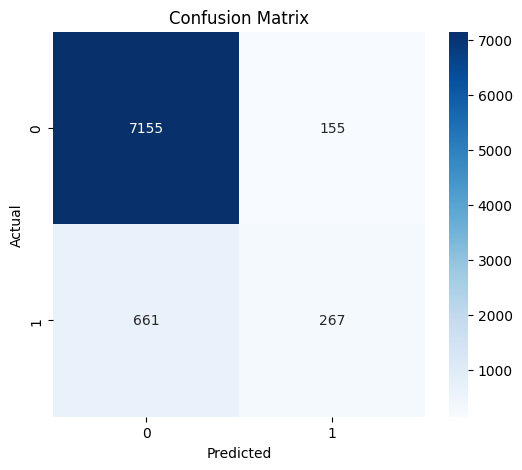

In [7]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC Curve

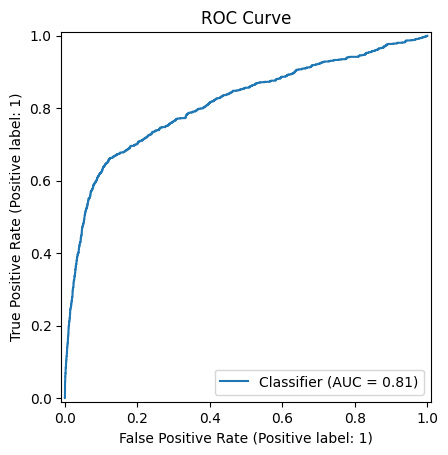

In [8]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

Precision Recall Curve

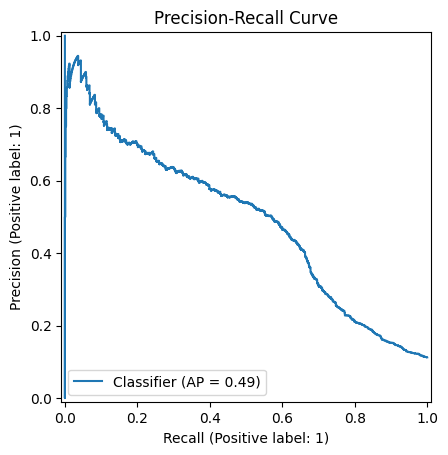

In [9]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve")
plt.show()

Business Summary

In [10]:
print("FINAL BUSINESS SUMMARY")

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print(f"ROC AUC   : {roc_auc*100:.2f}%")

print("\nRecommended Model: CatBoost")

print("\nBusiness Recommendation:")
print("- Target customers with the highest predicted response probability.")
print("- Reduce marketing cost by avoiding low-probability customers.")
print("- Improve campaign conversion rate.")
print("- Use the model as a decision-support tool for future campaigns.")

FINAL BUSINESS SUMMARY
Accuracy  : 90.09%
Precision : 63.27%
Recall    : 28.77%
F1 Score  : 39.56%
ROC AUC   : 81.23%

Recommended Model: CatBoost

Business Recommendation:
- Target customers with the highest predicted response probability.
- Reduce marketing cost by avoiding low-probability customers.
- Improve campaign conversion rate.
- Use the model as a decision-support tool for future campaigns.


Profit Simulation Table

In [11]:
# Create prediction dataframe

results_df = X_test.copy()

results_df["Actual"] = y_test.values
results_df["Probability"] = y_prob

results_df = results_df.sort_values(
    by="Probability",
    ascending=False
)

results_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,euribor3m,nr.employed,previous_contact,multiple_contacts,is_senior,stable_job,summer_contact,cluster,Actual,Probability
7127,64,retired,married,university.degree,no,no,no,cellular,mar,fri,...,0.653,5008.7,1,0,1,1,0,2,0,0.987191
4887,92,retired,married,unknown,no,no,yes,cellular,aug,wed,...,0.903,4991.6,1,0,1,1,1,2,1,0.970045
311,98,retired,married,basic.4y,unknown,yes,no,cellular,oct,fri,...,0.730,5017.5,1,0,1,1,0,2,1,0.962660
3020,65,management,married,unknown,no,no,no,cellular,dec,wed,...,0.715,5023.5,1,1,1,1,0,2,1,0.962431
4500,34,admin.,single,university.degree,no,no,no,cellular,mar,tue,...,0.652,5008.7,1,0,0,1,0,2,1,0.959669


In [12]:
total = len(results_df)

segments = [10,20,30,100]

profit_table = []

for pct in segments:

    n = int(total * pct / 100)

    temp = results_df.head(n)

    responders = temp["Actual"].sum()

    profit_table.append({
        "Top % Customers": pct,
        "Customers": n,
        "Responders": responders,
        "Response Rate (%)": responders/n*100
    })

profit_df = pd.DataFrame(profit_table)

profit_df

,Top % Customers,Customers,Responders,Response Rate (%)
0,10,823,448,54.434994
1,20,1647,622,37.765634
2,30,2471,682,27.600162
3,100,8238,928,11.264870


Save Table

In [13]:
profit_df.to_csv(
    "../reports/profit_simulation.csv",
    index=False
)

profit_df

,Top % Customers,Customers,Responders,Response Rate (%)
0,10,823,448,54.434994
1,20,1647,622,37.765634
2,30,2471,682,27.600162
3,100,8238,928,11.264870


Threshold Optimization

In [14]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1,0.91,0.05)

scores=[]

for t in thresholds:

    pred=(y_prob>=t).astype(int)

    scores.append(f1_score(y_test,pred))

best_index=np.argmax(scores)

best_threshold=thresholds[best_index]

print("Best Threshold:",best_threshold)
print("Best F1:",scores[best_index])

Best Threshold: 0.25000000000000006
Best F1: 0.5322245322245323


Threshold Graph

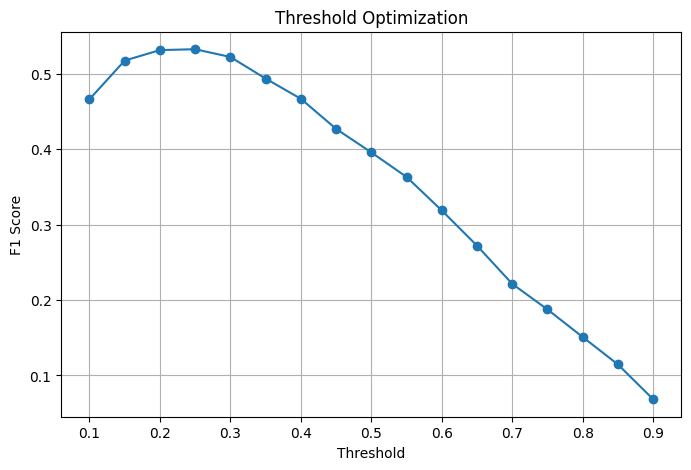

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    scores,
    marker="o"
)

plt.xlabel("Threshold")

plt.ylabel("F1 Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.show()

Save Final Model

In [16]:
import joblib

joblib.dump(
    best_model,
    "../models/final_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


Final Conclusion

In [17]:
print("PROJECT COMPLETED SUCCESSFULLY")

print("Dataset : Bank Marketing")

print("Problem : Campaign Response Prediction")

print("Best Model : CatBoost")

print(f"ROC-AUC : {roc_auc*100:.2f}%")

print(f"Accuracy : {accuracy*100:.2f}%")

print(f"Best Threshold : {best_threshold:.2f}")

print("\nBusiness Impact")

print("- Better customer targeting")

print("- Lower marketing cost")

print("- Higher campaign conversion")

print("- Data-driven decision making")

PROJECT COMPLETED SUCCESSFULLY
Dataset : Bank Marketing
Problem : Campaign Response Prediction
Best Model : CatBoost
ROC-AUC : 81.23%
Accuracy : 90.09%
Best Threshold : 0.25

Business Impact
- Better customer targeting
- Lower marketing cost
- Higher campaign conversion
- Data-driven decision making


Save Final Metrics

In [18]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score (%)": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        roc_auc * 100
    ]
})

final_results.to_csv(
    "../reports/final_model_metrics.csv",
    index=False
)

final_results

,Metric,Score (%)
0,Accuracy,90.094683
1,Precision,63.270142
2,Recall,28.771552
3,F1 Score,39.555556
4,ROC-AUC,81.234072


Create Project Summary

In [19]:
summary = f"""
PROJECT SUMMARY
==============================

Project:
Marketing Campaign Response Modelling

Objective:
Predict customers who are most likely to respond to a marketing campaign.

Dataset:
UCI Bank Marketing Dataset

Best Model:
CatBoost Classifier

Evaluation Metrics
-----------------------
Accuracy : {accuracy*100:.2f}%
Precision: {precision*100:.2f}%
Recall   : {recall*100:.2f}%
F1 Score : {f1*100:.2f}%
ROC AUC  : {roc_auc*100:.2f}%

Business Value
-----------------------
• Reduce unnecessary campaign cost.
• Improve response rate.
• Better customer targeting.
• Support data-driven marketing decisions.

End of Report.
"""

with open("../reports/project_summary.txt","w") as f:
    f.write(summary)

print(summary)


PROJECT SUMMARY

Project:
Marketing Campaign Response Modelling

Objective:
Predict customers who are most likely to respond to a marketing campaign.

Dataset:
UCI Bank Marketing Dataset

Best Model:
CatBoost Classifier

Evaluation Metrics
-----------------------
Accuracy : 90.09%
Precision: 63.27%
Recall   : 28.77%
F1 Score : 39.56%
ROC AUC  : 81.23%

Business Value
-----------------------
• Reduce unnecessary campaign cost.
• Improve response rate.
• Better customer targeting.
• Support data-driven marketing decisions.

End of Report.



Verify Files

In [20]:
import os

folders = [
    "../models",
    "../reports",
    "../mlruns"
]

for folder in folders:
    print(f"\nContents of {folder}:")
    if os.path.exists(folder):
        print(os.listdir(folder))
    else:
        print("Folder not found.")


Contents of ../models:
['best_model.pkl', 'catboost_model.pkl', 'final_model.pkl', 'lightgbm_model.pkl', 'logistic_regression.pkl', 'preprocessor.pkl', 'random_forest.pkl', 'xgboost_model.pkl']

Contents of ../reports:
['baseline_model_comparison.csv', 'cluster_profile.csv', 'cluster_target_analysis.csv', 'dataset_information.csv', 'Figures', 'final_model_metrics.csv', 'numerical_summary.csv', 'Profiling', 'profit_simulation.csv', 'project_summary.txt', 'Tables', 'target_summary.csv']

Contents of ../mlruns:
[]
